## Imports

In [1]:
import joblib
import numpy as np
import pandas as pd

import time
import shap
import matplotlib.pyplot as plt

from pathlib import Path

## Load the final model bundle

In [2]:
model_path = Path("../models/airline_fraud_xgboost.joblib")

bundle = joblib.load(model_path)

preprocessor = bundle["preprocessor"]
model = bundle["model"]
threshold = bundle["threshold"]
metadata = bundle["metadata"]

In [3]:
threshold

0.91

### Inspect what we're actually explaining

In [4]:
feature_names = preprocessor.get_feature_names_out()

print(f"Number of transformed features: {len(feature_names)}")
print(feature_names)

Number of transformed features: 1597
['num__amount' 'num__account_age_days' 'num__transaction_hour' ...
 'cat__currency_INR' 'cat__currency_JPY' 'cat__currency_USD']


## Build the Feature Mapping

In [5]:
for name, transformer, columns in preprocessor.transformers_:
    print(f"{name}:")
    print(f"  Columns: {list(columns)}")
    print(f"  Transformer: {type(transformer).__name__}")

num:
  Columns: ['amount', 'account_age_days', 'transaction_hour', 'transaction_dayofweek']
  Transformer: FunctionTransformer
cat:
  Columns: ['billing_country', 'route', 'card_bin', 'currency']
  Transformer: OneHotEncoder


### Inspect the Fitted Categorical Encoder

In [6]:
encoder = preprocessor.named_transformers_["cat"]
categorical_columns = preprocessor.transformers_[1][2]

for feature, categories in zip(categorical_columns, encoder.categories_):
    print(f"{feature}: {len(categories)} categories")

billing_country: 4 categories
route: 1558 categories
card_bin: 24 categories
currency: 7 categories


Our fitted object essentially contains:
```
preprocessor.transformers_
│
├── [0]
│    ├── "num"
│    ├── FunctionTransformer
│    └── ['amount', 'account_age_days',
│         'transaction_hour', 'transaction_dayofweek']
│
└── [1]
     ├── "cat"
     ├── OneHotEncoder
     └── ['billing_country', 'route',
          'card_bin', 'currency']
```
So `preprocessor.transformers_[1]` means: **Give me the second transformer, which is our categorical transformer.** And that tuple has three elements:

- [0] → transformer name
- [1] → transformer object
- [2] → columns assigned to it

Therefore `preprocessor.transformers_[1][2]` means: **From the second transformer (cat), give me the columns it operates on.** Which gives us: `["billing_country", "route", "card_bin", "currency"]`

### Inspect the actual transformed names by feature group

In [7]:
for feature, categories in zip(categorical_columns, encoder.categories_):
    print(f"\n{feature}")
    print(f"  Encoded features: {len(categories)}")
    print(f"  First 5 categories: {categories[:5]}")


billing_country
  Encoded features: 4
  First 5 categories: ['ES' 'GB' 'IN' 'US']

route
  Encoded features: 1558
  First 5 categories: ['AMS-ATL' 'AMS-BCN' 'AMS-BKK' 'AMS-BOM' 'AMS-CDG']

card_bin
  Encoded features: 24
  First 5 categories: ['140442' '207047' '220026' '238028' '294987']

currency
  Encoded features: 7
  First 5 categories: ['AUD' 'CAD' 'EUR' 'GBP' 'INR']


## Build and Validate the `1,597 ⇰ 8 mapping`

In [8]:
feature_mapping = {}

for feature in ["amount", "account_age_days", "transaction_hour", "transaction_dayofweek"]:
    feature_mapping[f"num__{feature}"] = feature

for feature in categorical_columns:
    prefix = f"cat__{feature}_"
    for transformed_feature in feature_names:
        if transformed_feature.startswith(prefix):
            feature_mapping[transformed_feature] = feature

print(f"Mapped features: {len(feature_mapping)}")
print(f"Unmapped features: {len(feature_names) - len(feature_mapping)}")

Mapped features: 1597
Unmapped features: 0


## One Final Validation of the Mapping

In [9]:
mapping_counts = pd.Series(feature_mapping).value_counts()

print(mapping_counts)
print(f"\nTotal mapped features: {mapping_counts.sum()}")

route                    1558
card_bin                   24
currency                    7
billing_country             4
amount                      1
account_age_days            1
transaction_hour            1
transaction_dayofweek       1
Name: count, dtype: int64

Total mapped features: 1597


## Load the Test Data

In [10]:
data_dir = Path("../data")

for path in data_dir.rglob("test.parquet"):
    print(path)

..\data\processed\modeling\test.parquet


In [11]:
test_path = Path("../data/processed/modeling/test.parquet")
test_data = pd.read_parquet(test_path, engine="pyarrow")

print(f"Test shape: {test_data.shape}")
print(f"Columns: {test_data.columns.tolist()}")
print(f"Missing values: {test_data.isna().sum().sum()}")

Test shape: (450335, 9)
Columns: ['amount', 'billing_country', 'route', 'card_bin', 'account_age_days', 'currency', 'transaction_hour', 'transaction_dayofweek', 'is_fraud']
Missing values: 0


### Inspect the test-set target distribution

In [12]:
print(test_data["is_fraud"].value_counts())
print(test_data["is_fraud"].value_counts(normalize=True).mul(100).round(2))

is_fraud
0    443577
1      6758
Name: count, dtype: int64
is_fraud
0    98.5
1     1.5
Name: proportion, dtype: float64


## Create the initial stratified SHAP sample

In [13]:
shap_sample = (
    test_data
    .groupby("is_fraud", group_keys=False)
    .sample(frac=2000 / len(test_data), random_state=42)
)

print(f"SHAP sample shape: {shap_sample.shape}")
print(shap_sample["is_fraud"].value_counts())
print(
    shap_sample["is_fraud"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

SHAP sample shape: (2000, 9)
is_fraud
0    1970
1      30
Name: count, dtype: int64
is_fraud
0    98.5
1     1.5
Name: proportion, dtype: float64


**Why 2,000?**
- Small enough to benchmark safely.
- Large enough to give us some fraud examples.
- Reproducible with `random_state`.
- We can increase it later if the SHAP runtime is comfortably low.
- We're not claiming 2,000 is our final global sample yet.

For the eventual global analysis, we may settle on a larger sample after seeing the benchmark.

## Prepare the SHAP sample for the fitted model

In [14]:
X_shap = shap_sample.drop(columns="is_fraud")
X_shap_transformed = preprocessor.transform(X_shap)

print(f"Original SHAP sample shape: {X_shap.shape}")
print(f"Transformed SHAP sample shape: {X_shap_transformed.shape}")

Original SHAP sample shape: (2000, 8)
Transformed SHAP sample shape: (2000, 1597)


## Initialize the TreeExplainer

In [15]:
explainer = shap.TreeExplainer(model)

print("SHAP TreeExplainer initialized successfully. ✅")

SHAP TreeExplainer initialized successfully. ✅


## Benchmark SHAP computation

In [16]:
start_time = time.perf_counter()

shap_values = explainer(X_shap_transformed)

elapsed = time.perf_counter() - start_time

print(f"SHAP computation completed in {elapsed:.2f} seconds.")
print(f"SHAP values shape: {shap_values.values.shape}")

SHAP computation completed in 1.50 seconds.
SHAP values shape: (2000, 1597)


### Inspect the SHAP output structure

In [17]:
print(f"SHAP values shape: {shap_values.values.shape}")
print(f"Base values shape: {np.asarray(shap_values.base_values).shape}")
print(f"Data shape: {shap_values.data.shape}")

SHAP values shape: (2000, 1597)
Base values shape: (2000,)
Data shape: (2000, 1597)


In [18]:
print(f"SHAP model output: {explainer.model_output}")
print(f"Feature perturbation: {explainer.feature_perturbation}")

SHAP model output: raw
Feature perturbation: tree_path_dependent


In [19]:
fraud_sample_size = round(10_000 * test_data["is_fraud"].mean())
nonfraud_sample_size = 10_000 - fraud_sample_size

print(f"Fraud sample size: {fraud_sample_size}")
print(f"Non-fraud sample size: {nonfraud_sample_size}")

Fraud sample size: 150
Non-fraud sample size: 9850


## Create the 10,000-row global sample

In [20]:
global_shap_sample = pd.concat(
    [
        test_data[test_data["is_fraud"] == 0].sample(
            n=nonfraud_sample_size,
            random_state=42
        ),
        test_data[test_data["is_fraud"] == 1].sample(
            n=fraud_sample_size,
            random_state=42
        ),
    ]
).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Global SHAP sample shape: {global_shap_sample.shape}")
print(global_shap_sample["is_fraud"].value_counts())

Global SHAP sample shape: (10000, 9)
is_fraud
0    9850
1     150
Name: count, dtype: int64


## Prepare the final global SHAP input

In [21]:
X_global_shap = global_shap_sample.drop(columns="is_fraud")
X_global_shap_transformed = preprocessor.transform(X_global_shap)

print(f"Original shape: {X_global_shap.shape}")
print(f"Transformed shape: {X_global_shap_transformed.shape}")

Original shape: (10000, 8)
Transformed shape: (10000, 1597)


## Compute global SHAP values

In [22]:
start_time = time.perf_counter()

global_shap_values = explainer(X_global_shap_transformed)

elapsed = time.perf_counter() - start_time

print(f"Global SHAP computation completed in {elapsed:.2f} seconds.")
print(f"SHAP values shape: {global_shap_values.values.shape}")

Global SHAP computation completed in 6.75 seconds.
SHAP values shape: (10000, 1597)


For global importance, we're interested in:

> **How much does this original feature contribute to model output on average?**

So we'll calculate:

$$
\text{Mean Absolute SHAP}_j
=

\frac{1}{n}
\sum_i |\text{SHAP}_{ij}|
$$

at the **original feature-group level**.

### Create the transformed-feature mapping Series

In [23]:
feature_groups = pd.Series(
    [feature_mapping[name] for name in feature_names],
    index=feature_names,
    name="original_feature"
)

print(feature_groups.head())
print()
print(feature_groups.value_counts())

num__amount                                  amount
num__account_age_days              account_age_days
num__transaction_hour              transaction_hour
num__transaction_dayofweek    transaction_dayofweek
cat__billing_country_ES             billing_country
Name: original_feature, dtype: str

original_feature
route                    1558
card_bin                   24
currency                    7
billing_country             4
amount                      1
account_age_days            1
transaction_hour            1
transaction_dayofweek       1
Name: count, dtype: int64


## Calculate grouped global SHAP importance

In [24]:
shap_abs = np.abs(global_shap_values.values)

shap_abs_df = pd.DataFrame(
    shap_abs,
    columns=feature_names
)

global_importance = (
    shap_abs_df.T
    .groupby(feature_groups)
    .sum()
    .T
    .mean()
    .sort_values(ascending=False)
)

print(global_importance)

original_feature
card_bin                 0.879992
amount                   0.859917
route                    0.459561
account_age_days         0.442759
billing_country          0.353014
transaction_dayofweek    0.089614
transaction_hour         0.068002
currency                 0.017917
dtype: float32


## Quantify the relative contribution

In [25]:
global_importance_pct = (
    global_importance
    .div(global_importance.sum())
    .mul(100)
    .round(2)
)

global_importance_table = pd.DataFrame({
    "mean_abs_shap": global_importance.round(4),
    "importance_pct": global_importance_pct
})

print(global_importance_table)

                       mean_abs_shap  importance_pct
original_feature                                    
card_bin                      0.8800       27.750000
amount                        0.8599       27.120001
route                         0.4596       14.490000
account_age_days              0.4428       13.960000
billing_country               0.3530       11.130000
transaction_dayofweek         0.0896        2.830000
transaction_hour              0.0680        2.140000
currency                      0.0179        0.570000


## First Global Visualization

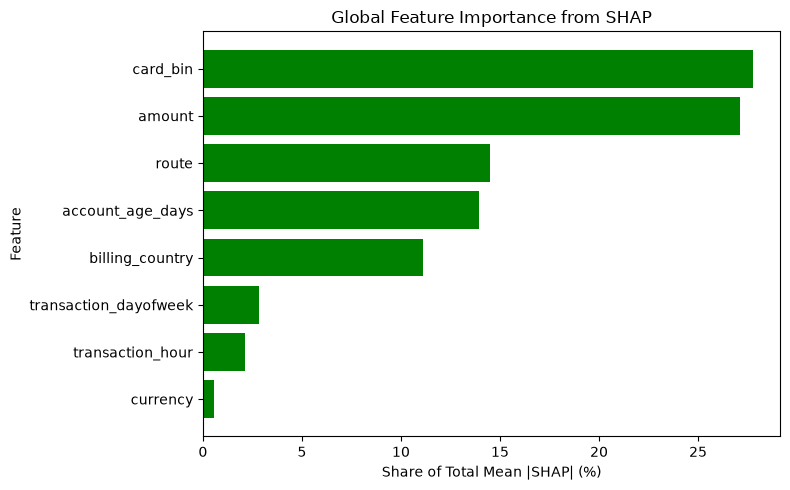

In [26]:
plot_data = global_importance_pct.sort_values()

plt.figure(figsize=(8, 5))
plt.barh(plot_data.index, plot_data.values, color="g")

plt.xlabel("Share of Total Mean |SHAP| (%)")
plt.ylabel("Feature")
plt.title("Global Feature Importance from SHAP")

plt.tight_layout()
plt.show()

In [27]:
shap_signed_df = pd.DataFrame(
    global_shap_values.values,
    columns=feature_names
)

global_direction = (
    shap_signed_df.T
    .groupby(feature_groups)
    .sum()
    .T
    .mean()
    .sort_values()
)

global_direction

original_feature
amount                  -0.619208
card_bin                -0.423782
account_age_days        -0.160891
route                   -0.082102
transaction_hour        -0.034951
transaction_dayofweek   -0.021214
currency                -0.007787
billing_country          0.076914
dtype: float32

> A negative mean SHAP value does not mean "higher amount lowers fraud risk."

It only means that, across these observations, the combined contribution associated with amount was more often/tended to be toward the lower side of the model's raw output.

### Inspect `amount` SHAP behavior

In [28]:
amount_shap = global_shap_values[:, list(feature_names).index("num__amount")]

print(f"Amount SHAP values: {amount_shap.values.shape}")
print(
    f"SHAP range: "
    f"{amount_shap.values.min():.4f} to {amount_shap.values.max():.4f}"
)

Amount SHAP values: (10000,)
SHAP range: -2.4466 to 8.6198


## `amount` value vs SHAP contribution

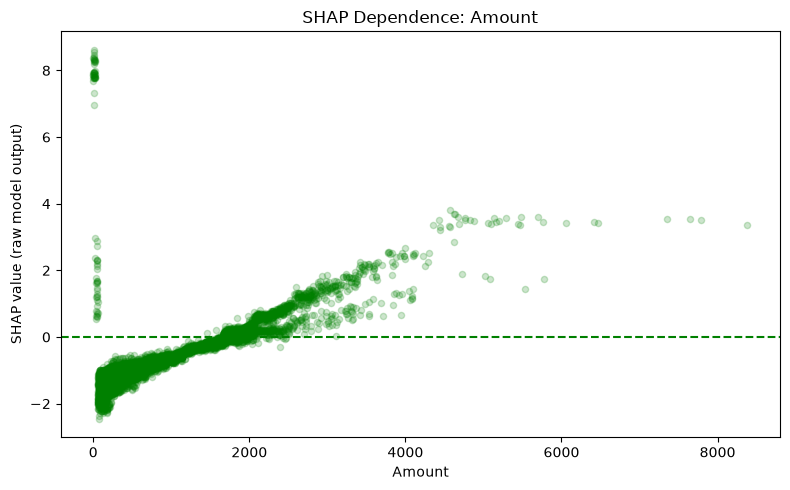

In [29]:
plt.figure(figsize=(8, 5))

plt.scatter(X_global_shap["amount"],
    amount_shap.values,
    s=20,
    alpha=0.2,
    c="g"
)

plt.axhline(0, linestyle="--", c="g")

plt.xlabel("Amount")
plt.ylabel("SHAP value (raw model output)")
plt.title("SHAP Dependence: Amount")

plt.tight_layout()
plt.show()

* Overall Trend: As the Amount increases, its impact on the model prediction changes from negative to positive.
* Lower Amounts (0 to 1,800): These values have a negative impact, pulling the model's raw prediction down (SHAP values between -2 and 0).
* Neutral Point (~1,800): An Amount around 1,800 has a neutral impact (SHAP value is exactly 0).
* Higher Amounts (1,800 to 4,000): These values have a positive impact, pushing the model's prediction up linearly.
* Plateau Effect (> 4,000): Once the Amount exceeds 4,000, the impact flattens out and saturates around a SHAP value of +3.5.

**Hidden Patterns & Interactions**

* Vertical Split near 0: For very small amounts, a small group of data points spikes to a high positive SHAP value (+1 to +8.5).
* Branching / Splitting: Between 2,000 and 4,000, the data splits into two distinct vertical paths.
* Meaning: Both patterns strongly indicate an interaction effect, meaning the impact of Amount changes depending on the value of a second unnamed feature.

### Find potential interaction partners for `amount`

In [30]:
amount_index = list(feature_names).index("num__amount")

interaction_indices = shap.approximate_interactions(
    amount_index,
    global_shap_values.values,
    X_global_shap_transformed.toarray()  # Convert to a dense NumPy array
)

print("Top 10 potential interaction features with amount:")

for rank, index in enumerate(interaction_indices[:10], start=1):
    print(f"{rank}. {feature_names[index]}")

Top 10 potential interaction features with amount:
1. num__account_age_days
2. cat__card_bin_762572
3. cat__card_bin_552739
4. cat__billing_country_US
5. cat__card_bin_315234
6. cat__billing_country_ES
7. cat__currency_GBP
8. cat__card_bin_806155
9. cat__billing_country_GB
10. cat__currency_CAD


## Let's test the strongest candidate visually

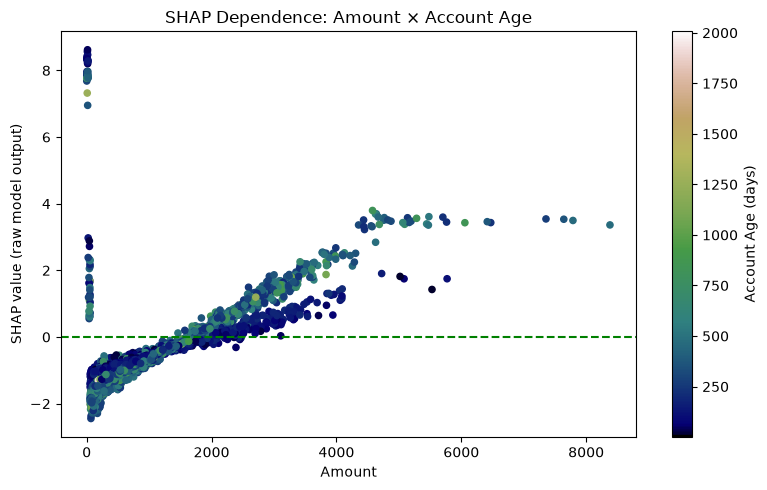

In [31]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_global_shap["amount"],
    amount_shap.values,
    c=X_global_shap["account_age_days"],
    s=20,
    cmap="gist_earth"
)

plt.axhline(0, linestyle="--", c="g")

plt.xlabel("Amount")
plt.ylabel("SHAP value (raw model output)")
plt.title("SHAP Dependence: Amount × Account Age")

plt.colorbar(label="Account Age (days)")

plt.tight_layout()
plt.show()

* The High Spike Near 0: The group of points with a high positive SHAP value (+6 to +8.5) consists of newer accounts (dark blue/purple dots, mostly under 250 days old).
* Meaning: When the transaction Amount is close to zero, it drastically increases the model's output prediction only if the account is very new.
* The Main Linear Split (Amounts 2,000 to 4,000):
* Top Branch (Green/Teal): These are older accounts (roughly 500 to 1,500 days old). For a given amount in this range, older accounts push the prediction higher.
   * Bottom Branch (Dark Blue): These are newer accounts (under 250 days old). For the same amount, newer accounts keep the prediction closer to neutral (around 0 to +1).
* The Saturated Plateau (> 4,000): The points that level off at the top are primarily medium-to-older accounts (green and light blue). The few points that dip lower after 4,000 belong to very young accounts.

Summary of the Interaction: The model treats the transaction Amount differently based on how long the account has been active. Low amounts on brand-new accounts cause a major risk spike, while higher mid-range amounts have a stronger positive impact on established accounts.

### Investigate `account_age_days` itself

In [32]:
account_age_shap = global_shap_values[
    :,
    list(feature_names).index("num__account_age_days")
]

print(f"Account age SHAP values: {account_age_shap.values.shape}")
print(
    f"SHAP range: "
    f"{account_age_shap.values.min():.4f} to "
    f"{account_age_shap.values.max():.4f}"
)

Account age SHAP values: (10000,)
SHAP range: -3.1280 to 0.4531


### Account age dependence plot

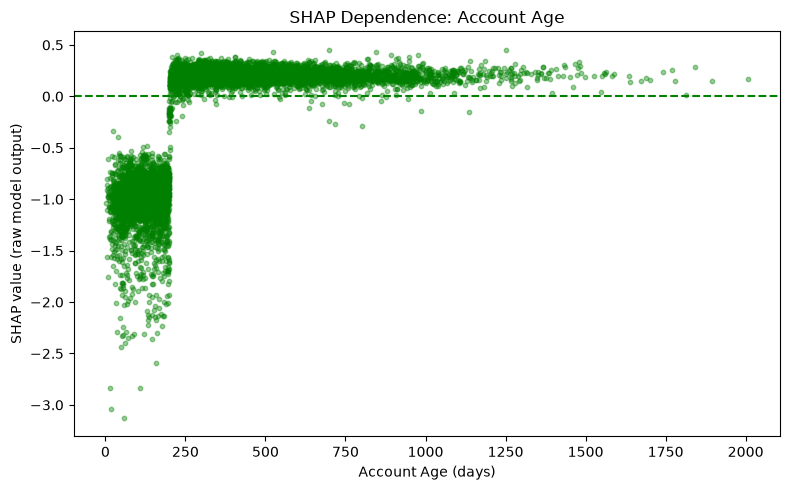

In [33]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_global_shap["account_age_days"],
    account_age_shap.values,
    s=10,
    alpha=0.4,
    c="g"
)

plt.axhline(0, linestyle="--", c="g")

plt.xlabel("Account Age (days)")
plt.ylabel("SHAP value (raw model output)")
plt.title("SHAP Dependence: Account Age")

plt.tight_layout()
plt.show()

* The 200-Day Step Function (The Cliff): There is a sharp, binary-like threshold at exactly 200 days. The model handles data before and after this cutoff with completely opposite logic.
* New Accounts (0 to 200 days):
* Having a new account has a strong negative impact on the model's prediction.
   * The SHAP values fall between -0.5 and -3.0.
   * The wide vertical spread in this region indicates that other features significantly modify how negative this impact is.
* Established Accounts (> 200 days):
* As soon as an account crosses the 200-day mark, the impact instantly jumps to a slightly positive, stable baseline (SHAP values tightly clustered between 0.0 and +0.4).
   * After 200 days, the impact remains incredibly flat and uniform, meaning an account age of 300 days is treated almost identically to an account age of 2,000 days.

Data Science Takeaway: The model has essentially learned a hard rule rather than a smooth progression. It views any account under 200 days old as a unique, highly variable risk category, while treating any account older than 200 days as a standard, safe baseline.

### But let's verify that interaction from the other direction

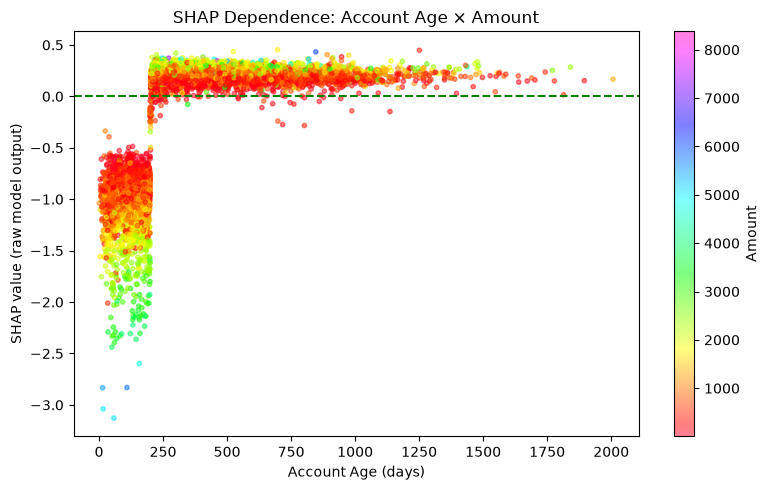

In [34]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_global_shap["account_age_days"],
    account_age_shap.values,
    c=X_global_shap["amount"],
    s=10,
    alpha=0.5,
    cmap="gist_rainbow"
)

plt.axhline(0, linestyle="--", c="g")

plt.xlabel("Account Age (days)")
plt.ylabel("SHAP value (raw model output)")
plt.title("SHAP Dependence: Account Age × Amount")

plt.colorbar(label="Amount")

plt.tight_layout()
plt.show()

* The Spread on New Accounts (< 200 Days):
* Small Amounts (Red/Orange): When a brand-new account has a low transaction amount (under 1,000), the SHAP value is only mildly negative (around -0.5 to -1.0).
   * Large Amounts (Green/Blue): As the transaction amount increases (3,000 to 6,000+), the SHAP value drops sharply down to -2.5 and -3.0.
   * Meaning: For new accounts, larger transaction amounts trigger a much heavier penalty from the model.
* The Spike Near Zero Days (Light Blue/Pink): At the absolute bottom left (near 0 days old), you see a few bright blue and pink dots stretching down to -3.0. This means a massive transaction amount on a brand-new account (0–50 days old) receives the maximum possible negative penalty.
* Post 200-Day Behavior:
* Once the account crosses the 200-day threshold, the colors blend completely together at the top baseline (+0.1 to +0.4).
   * Meaning: After an account is 200 days old, the transaction Amount no longer interacts heavily with Account Age. Whether the amount is $100 (red) or $8,000 (pink), the model treats the account age with the same stable, slightly positive impact.

Strategic Summary: The model applies a combined risk rule: New Account + High Amount = Extreme Negative Penalty. Once the account matures past 200 days, this specific penalty rule is completely deactivated.

## Validate this before our interpretation summary

In [35]:
young = X_global_shap["account_age_days"] < 200
established = ~young

young_corr = np.corrcoef(
    X_global_shap.loc[young, "amount"],
    account_age_shap.values[young]
)[0, 1]

established_corr = np.corrcoef(
    X_global_shap.loc[established, "amount"],
    account_age_shap.values[established]
)[0, 1]

print(f"Young accounts (<200 days): correlation = {young_corr:.3f}")
print(f"Established accounts (>=200 days): correlation = {established_corr:.3f}")

Young accounts (<200 days): correlation = -0.802
Established accounts (>=200 days): correlation = 0.484


## Build the final global interpretation table

In [36]:
global_interpretation = pd.DataFrame({
    "feature": global_importance.index,
    "mean_abs_shap": global_importance.values,
    "importance_pct": global_importance_pct.loc[global_importance.index].values,
    "mean_signed_shap": global_direction.loc[global_importance.index].values
}).reset_index(drop=True)

global_interpretation

,feature,mean_abs_shap,importance_pct,mean_signed_shap
0,card_bin,0.879992,27.750000,-0.423782
1,amount,0.859917,27.120001,-0.619208
2,route,0.459561,14.490000,-0.082102
3,account_age_days,0.442759,13.960000,-0.160891
4,billing_country,0.353014,11.130000,0.076914
5,transaction_dayofweek,0.089614,2.830000,-0.021214
6,transaction_hour,0.068002,2.140000,-0.034951
7,currency,0.017917,0.570000,-0.007787


# **Local explanations**

## Score the global SHAP sample

In [37]:
global_probabilities = model.predict_proba(
    X_global_shap_transformed
)[:, 1]

local_candidates = global_shap_sample.copy()
local_candidates["fraud_probability"] = global_probabilities

print(
    local_candidates["fraud_probability"]
    .describe()
)

count    10000.000000
mean         0.254213
std          0.171259
min          0.017528
25%          0.134251
50%          0.215872
75%          0.319880
max          0.999769
Name: fraud_probability, dtype: float64


## Select the three local cases

In [39]:
high_risk_idx = local_candidates["fraud_probability"].idxmax()
low_risk_idx = local_candidates["fraud_probability"].idxmin()

near_threshold_idx = (
    local_candidates["fraud_probability"]
    .sub(threshold)
    .abs()
    .idxmin()
)

local_cases = local_candidates.loc[
    [high_risk_idx, low_risk_idx, near_threshold_idx]
].copy()

local_cases.insert(
    0, "case",
    ["high_risk", "low_risk", "near_threshold"]
)

local_cases[
    [
        "case",
        "fraud_probability",
        "is_fraud",
        "amount",
        "billing_country",
        "route",
        "card_bin",
        "account_age_days",
        "currency",
        "transaction_hour",
        "transaction_dayofweek",
    ]
]

,case,fraud_probability,is_fraud,amount,billing_country,route,card_bin,account_age_days,currency,transaction_hour,transaction_dayofweek
3051,high_risk,0.999769,1,1.14,US,DEN-MCO,552739,300,EUR,21,3
9951,low_risk,0.017528,0,727.10,US,CDG-HAN,552739,150,USD,20,5
7474,near_threshold,0.908906,0,2904.52,GB,MEL-BKK,806155,279,AUD,9,6


## Extract the three local SHAP explanations

In [40]:
local_indices = [high_risk_idx, low_risk_idx, near_threshold_idx]

local_shap_values = global_shap_values[local_indices]

print(f"Local SHAP shape: {local_shap_values.values.shape}")
print(f"Local cases: {len(local_indices)}")

Local SHAP shape: (3, 1597)
Local cases: 3


## Aggregate local SHAP contributions to the 8 original features

In [ ]:
local_shap_df = pd.DataFrame(
    local_shap_values.values,
    columns=feature_names
)

local_shap_grouped = (
    local_shap_df.T
    .groupby(feature_groups)
    .sum()
    .T
)

local_shap_grouped.index = [
    "high_risk",
    "low_risk",
    "near_threshold"
]

print(local_shap_grouped.round(4))

original_feature  account_age_days  amount  billing_country  card_bin  \
high_risk                   0.1404  7.6826           0.2076   -0.3890   
low_risk                   -1.2589 -0.7759           0.1948   -0.9954   
near_threshold              0.3118  1.6908           0.1627   -0.4531   

original_feature  currency   route  transaction_dayofweek  transaction_hour  
high_risk          -0.0008  0.4794                 0.0673            0.1320  
low_risk           -0.0189 -0.8598                -0.3229           -0.0424  
near_threshold      0.0029  0.5579                -0.0406            0.0148  


## Rank local contributions

In [42]:
local_contribution_tables = {}

for case in local_shap_grouped.index:
    contributions = local_shap_grouped.loc[case].sort_values(
        key=np.abs,
        ascending=False
    )
    
    local_contribution_tables[case] = contributions

    print(f"\n{case}")
    print(contributions.round(4))


high_risk
original_feature
amount                   7.6826
route                    0.4794
card_bin                -0.3890
billing_country          0.2076
account_age_days         0.1404
transaction_hour         0.1320
transaction_dayofweek    0.0673
currency                -0.0008
Name: high_risk, dtype: float32

low_risk
original_feature
account_age_days        -1.2589
card_bin                -0.9954
route                   -0.8598
amount                  -0.7759
transaction_dayofweek   -0.3229
billing_country          0.1948
transaction_hour        -0.0424
currency                -0.0189
Name: low_risk, dtype: float32

near_threshold
original_feature
amount                   1.6908
route                    0.5579
card_bin                -0.4531
account_age_days         0.3118
billing_country          0.1627
transaction_dayofweek   -0.0406
transaction_hour         0.0148
currency                 0.0029
Name: near_threshold, dtype: float32


But we still need one technical validation that is genuinely worth doing:

> **Do the grouped 8-feature SHAP contributions still add up to the model's raw output?**

Because we aggregated 1,597 SHAP values ⇰ 8 groups. We should verify that we haven't accidentally lost or altered any contribution during grouping.

If:

$$
\text{base value}+\sum_{8\ features} SHAP = \text{model raw output}
$$

then our grouping is mathematically preserving the original SHAP explanation.

## Validate local SHAP additivity

In [44]:
local_raw_output = model.predict(
    preprocessor.transform(
        local_cases.drop(columns=["case", "fraud_probability"])
    ),
    output_margin=True
)

local_base_values = np.asarray(local_shap_values.base_values)

local_additivity = pd.DataFrame({
    "case": local_shap_grouped.index,
    "base_value": local_base_values,
    "sum_shap": local_shap_grouped.sum(axis=1).values,
    "base_plus_shap": (
        local_base_values
        + local_shap_grouped.sum(axis=1).values
    ),
    "model_raw_output": local_raw_output,
})

local_additivity["difference"] = (
    local_additivity["base_plus_shap"]
    - local_additivity["model_raw_output"]
)

local_additivity.round(6)

,case,base_value,sum_shap,base_plus_shap,model_raw_output,difference
0,high_risk,0.053175,8.319395,8.372570,8.372564,0.000006
1,low_risk,0.053175,-4.079425,-4.026250,-4.026250,0.000000
2,near_threshold,0.053175,2.247170,2.300346,2.300344,0.000001


That's just floating-point noise. So we can confidently say:

> The 1,597 transformed SHAP contributions were aggregated into the 8 original feature groups without losing the additive explanation.

## Build local explanation summaries

In [45]:
local_explanation_summary = {}

for case in local_shap_grouped.index:
    contributions = local_shap_grouped.loc[case]

    positive = contributions[contributions > 0].sort_values(
        ascending=False
    ).head(3)

    negative = contributions[contributions < 0].sort_values(
        ascending=True
    ).head(3)

    local_explanation_summary[case] = {
        "positive": positive,
        "negative": negative
    }

    print(f"\n{'=' * 50}")
    print(case.upper())
    print("Top positive contributors:")
    print(positive.round(4))
    print("Top negative contributors:")
    print(negative.round(4))


HIGH_RISK
Top positive contributors:
original_feature
amount             7.6826
route              0.4794
billing_country    0.2076
Name: high_risk, dtype: float32
Top negative contributors:
original_feature
card_bin   -0.3890
currency   -0.0008
Name: high_risk, dtype: float32

LOW_RISK
Top positive contributors:
original_feature
billing_country    0.1948
Name: low_risk, dtype: float32
Top negative contributors:
original_feature
account_age_days   -1.2589
card_bin           -0.9954
route              -0.8598
Name: low_risk, dtype: float32

NEAR_THRESHOLD
Top positive contributors:
original_feature
amount              1.6908
route               0.5579
account_age_days    0.3118
Name: near_threshold, dtype: float32
Top negative contributors:
original_feature
card_bin                -0.4531
transaction_dayofweek   -0.0406
Name: near_threshold, dtype: float32


## Final local decision summary

In [46]:
local_decision_summary = local_cases[
    ["case", "fraud_probability", "is_fraud"]
].copy()

local_decision_summary["model_decision"] = np.where(
    local_decision_summary["fraud_probability"] >= threshold,
    "Flag",
    "Approve"
)

local_decision_summary["distance_from_threshold"] = (
    local_decision_summary["fraud_probability"] - threshold
).round(4)

local_decision_summary = local_decision_summary[
    [
        "case",
        "fraud_probability",
        "distance_from_threshold",
        "model_decision",
        "is_fraud"
    ]
]

local_decision_summary

,case,fraud_probability,distance_from_threshold,model_decision,is_fraud
3051,high_risk,0.999769,0.0898,Flag,1
9951,low_risk,0.017528,-0.8925,Approve,0
7474,near_threshold,0.908906,-0.0011,Approve,0


## Global Model Interpretation

SHAP analysis was performed on a representative 10,000-transaction sample from the test set. The transformed model inputs were mapped back to the eight original model features before interpreting feature importance.

The model's strongest feature groups were `card_bin` and `amount`, followed by `route`, `account_age_days`, and `billing_country`. These five features accounted for approximately 94.45% of the total grouped mean absolute SHAP contribution.

The analysis also revealed a strong interaction between `amount` and `account_age_days`. The effect of transaction amount on the model output changed substantially with account age, particularly for accounts below approximately 200 days.

`account_age_days` itself showed a threshold-like pattern around 200 days: younger accounts had substantially more variable SHAP contributions, while accounts above this point showed a much flatter contribution pattern.

The temporal features and especially `currency` had relatively small global SHAP contributions.

These findings describe how the final XGBoost model behaves; they do not imply that any feature is causally responsible for fraud.

## Local Explanations

Three test transactions were selected to illustrate different operating situations:

- **High-risk transaction:** Predicted fraud probability of 0.9998, well above the 0.91 operating threshold. The prediction was dominated by a strong positive contribution from `amount`, with smaller positive contributions from `route` and `billing_country`.
- **Low-risk transaction:** Predicted fraud probability of 0.0175. The strongest contributions pushing the prediction downward came from `account_age_days`, `card_bin`, and `route`.
- **Near-threshold transaction:** Predicted fraud probability of 0.9089, only 0.0011 below the operating threshold. `amount`, `route`, and `account_age_days` pushed the prediction upward, while `card_bin` pushed it downward. The model therefore remained just below the operational decision boundary.

The grouped local SHAP contributions were validated against the original model output, with only negligible floating-point differences.

## Interpretation Limitations (XAI limitations)

- SHAP explains the model's learned behavior; it does not establish causal relationships between features and fraud.
- SHAP values in this analysis represent contributions to the XGBoost model's raw output, not direct percentage-point changes in fraud probability.
- Global SHAP results were calculated on a representative sample of 10,000 test transactions rather than the full test set.
- Categorical variables were one-hot encoded for modeling and their SHAP contributions were aggregated back to the original feature groups for interpretation.
- Interaction patterns indicate model behavior and statistical association within the data; they should not be interpreted as causal effects.
- The model's explanations are limited to the features retained in the final modeling dataset. Dropped or unavailable transaction information cannot be evaluated through this model.

## Final XAI Summary

The final XGBoost model relies primarily on `card_bin`, `amount`, `route`, `account_age_days`, and `billing_country` when producing fraud-risk predictions.

The strongest individual signals were `card_bin` and `amount`, while `currency` and the temporal features contributed relatively little to the model's overall behavior.

The most notable interaction involved `amount` and `account_age_days`. The model's treatment of transaction amount changed substantially depending on account age, with particularly different behavior for accounts below approximately 200 days.

Local explanations showed that individual predictions can be driven by a combination of strong positive and negative feature contributions. The near-threshold example demonstrated this particularly well: several features pushed the prediction upward while others counteracted them, leaving the final probability just below the 0.91 operating threshold.

These explanations provide the evidence needed to move from model prediction to business decision-making. The next phase will translate model risk and model explanations into practical payment-risk recommendations.